# 🔬 Clasificación Inteligente de Cáncer de Piel usando Deep Learning

## Skin Cancer Classification with Convolutional Neural Networks

---

**Proyecto:** Clasificación binaria de lesiones cutáneas (Benigno vs Maligno)

**Modelo:** EfficientNetB0 con Transfer Learning

**Dataset:** HAM10000 (Skin Cancer MNIST)

**Técnicas:** Deep Learning, Computer Vision, Transfer Learning, Data Augmentation

---

## 1. Introducción al Problema

### 1.1 Contexto Médico

El cáncer de piel es uno de los tipos de cáncer más comunes a nivel mundial. La detección temprana es crucial para mejorar las tasas de supervivencia. Sin embargo, el diagnóstico visual requiere experiencia dermatológica especializada y puede ser subjetivo.

### 1.2 Importancia del Diagnóstico Temprano

- El melanoma detectado en etapa temprana tiene una tasa de supervivencia a 5 años superior al 99%
- En etapas avanzadas, esta tasa cae drásticamente por debajo del 30%
- La inteligencia artificial puede asistir en el screening inicial, priorizando casos sospechosos

### 1.3 Objetivos del Proyecto

1. Construir un clasificador binario de lesiones cutáneas usando Deep Learning
2. Implementar Transfer Learning con EfficientNetB0 pre-entrenado en ImageNet
3. Evaluar exhaustivamente el modelo en conjuntos de Train, Validation y Test
4. Generar métricas completas: Accuracy, Precision, Recall, F1-Score, ROC-AUC
5. Desplegar el modelo en una aplicación web con Streamlit y Docker

### 1.4 Metodología

```
Dataset HAM10000 → Preprocesamiento → Data Augmentation → CNN (EfficientNetB0)
    → Entrenamiento → Evaluación (Train/Val/Test) → Despliegue Web
```

## 2. Configuración del Entorno e Importación de Librerías

In [137]:
# ============================================
# IMPORTACION DE LIBRERIAS
# ============================================

import os
import sys
import warnings
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Dataset split
import splitfolders

# Configuracion
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.21.0
Keras version: 3.14.1
NumPy version: 2.4.4
GPU disponible: []


### 2.1 Optimización de Rendimiento - Máximo uso de recursos

Configuramos TensorFlow y el sistema para utilizar **todos los recursos disponibles** de la máquina (22 cores CPU, 31 GB RAM).

In [138]:
# ============================================
# OPTIMIZACIÓN DE RENDIMIENTO - MÁXIMO USO DE RECURSOS
# ============================================

import multiprocessing

# Detectar recursos del sistema
NUM_CORES = os.cpu_count()
print(f'CPU Cores disponibles: {NUM_CORES}')

# --- NOTA: Los threads de TF se configuran via variables de entorno ---
# Si reinicias el kernel, estas variables se aplican al importar TF
os.environ['TF_NUM_INTRAOP_THREADS'] = str(NUM_CORES)
os.environ['TF_NUM_INTEROP_THREADS'] = str(NUM_CORES)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

# Verificar configuracion actual de threads
intra = tf.config.threading.get_intra_op_parallelism_threads()
inter = tf.config.threading.get_inter_op_parallelism_threads()
# 0 significa que TF usa todos los cores disponibles automaticamente
intra_display = NUM_CORES if intra == 0 else intra
inter_display = NUM_CORES if inter == 0 else inter

# --- CONFIGURACIÓN DE WORKERS PARA DATA LOADING ---
# Usar múltiples workers para cargar datos en paralelo
WORKERS = max(1, NUM_CORES - 2)  # Dejar 2 cores libres para el sistema
USE_MULTIPROCESSING = True

# --- PREFETCH Y BUFFER ---
PREFETCH_BUFFER = tf.data.AUTOTUNE

# --- RESUMEN DE CONFIGURACIÓN ---
sep = '=' * 50
print(f'\n{sep}')
print(f'  CONFIGURACION DE RENDIMIENTO')
print(f'{sep}')
print(f'  CPU Cores totales: {NUM_CORES}')
print(f'  Threads intra-op (TF usa): {intra_display} cores')
print(f'  Threads inter-op (TF usa): {inter_display} cores')
print(f'  Workers data loading: {WORKERS}')
print(f'  Multiprocessing: {USE_MULTIPROCESSING}')
print(f'  oneDNN optimizations: Habilitado')
print(f'{sep}')
print(f'\n  TensorFlow ya usa todos los cores por defecto (valor 0 = auto).')
print(f'  Los {WORKERS} workers aceleraran la carga de datos en paralelo.')
print(f'  Esto maximiza el uso de tu CPU durante el entrenamiento.')

CPU Cores disponibles: 22

  CONFIGURACION DE RENDIMIENTO
  CPU Cores totales: 22
  Threads intra-op (TF usa): 22 cores
  Threads inter-op (TF usa): 22 cores
  Workers data loading: 20
  Multiprocessing: True
  oneDNN optimizations: Habilitado

  TensorFlow ya usa todos los cores por defecto (valor 0 = auto).
  Los 20 workers aceleraran la carga de datos en paralelo.
  Esto maximiza el uso de tu CPU durante el entrenamiento.


In [139]:
# ============================================
# CONFIGURACIÓN DE RUTAS DEL PROYECTO
# ============================================

# Directorio base del proyecto
BASE_DIR = os.path.dirname(os.getcwd())  # SkinCancerClassifier/
DATA_DIR = os.path.join(BASE_DIR, 'data')
RAW_DIR = os.path.join(DATA_DIR, 'raw')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

# Crear directorios
for d in [RAW_DIR, PROCESSED_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, MODELS_DIR,
          os.path.join(RESULTS_DIR, 'confusion_matrix'),
          os.path.join(RESULTS_DIR, 'roc_curves'),
          os.path.join(RESULTS_DIR, 'metrics'),
          os.path.join(RESULTS_DIR, 'training'),
          os.path.join(RESULTS_DIR, 'predictions')]:
    os.makedirs(d, exist_ok=True)

# Hiperparámetros
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001
NUM_CLASSES = 2
CLASS_NAMES = ['benign', 'malignant']

print('Configuración del proyecto:')
print(f'  Base dir: {BASE_DIR}')
print(f'  Image size: {IMG_SIZE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Epochs: {EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Classes: {CLASS_NAMES}')

Configuración del proyecto:
  Base dir: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier
  Image size: (224, 224)
  Batch size: 32
  Epochs: 20
  Learning rate: 0.001
  Classes: ['benign', 'malignant']


## 3. Dataset: HAM10000

### 3.1 Descripción del Dataset

El dataset **HAM10000** (Human Against Machine with 10000 training images) contiene:
- 10,015 imágenes dermatoscópicas de lesiones cutáneas
- 7 categorías diagnósticas diferentes
- Imágenes recopiladas durante más de 20 años
- Verificadas histopatológicamente

### 3.2 Mapeo a Clasificación Binaria

| Clase Original | Descripción | Clasificación |
|---|---|---|
| nv | Melanocytic nevi | **Benigno** |
| bkl | Benign keratosis | **Benigno** |
| df | Dermatofibroma | **Benigno** |
| vasc | Vascular lesions | **Benigno** |
| mel | Melanoma | **Maligno** |
| bcc | Basal cell carcinoma | **Maligno** |
| akiec | Actinic keratoses | **Maligno** |

### 3.3 Descarga del Dataset

In [140]:
# ============================================
# DESCARGA DEL DATASET HAM10000
# ============================================

import kagglehub

# Descargar dataset
print('Descargando dataset HAM10000...')
dataset_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')
print(f'Dataset descargado en: {dataset_path}')

# Listar contenido
print('\nContenido del dataset:')
for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        n_files = len(os.listdir(full_path))
        print(f'  [DIR] {item} ({n_files} archivos)')
    else:
        size = os.path.getsize(full_path) / 1024 / 1024
        print(f'  [FILE] {item} ({size:.1f} MB)')

Descargando dataset HAM10000...
Dataset descargado en: C:\Users\Sebas\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2

Contenido del dataset:
  [DIR] HAM10000_images_part_1 (5000 archivos)
  [DIR] HAM10000_images_part_2 (5015 archivos)
  [FILE] HAM10000_metadata.csv (0.5 MB)
  [FILE] hmnist_28_28_L.csv (29.4 MB)
  [FILE] hmnist_28_28_RGB.csv (87.6 MB)
  [FILE] hmnist_8_8_L.csv (2.4 MB)
  [FILE] hmnist_8_8_RGB.csv (7.2 MB)


## 4. Exploración del Dataset (EDA)

In [141]:
# ============================================
# CARGAR METADATA
# ============================================

# Buscar archivo de metadata
metadata_path = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if 'metadata' in f.lower() and f.endswith('.csv'):
            metadata_path = os.path.join(root, f)
            break

print(f'Metadata encontrada: {metadata_path}')
df = pd.read_csv(metadata_path)

# Información general
print(f'\nDimensiones del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'\nPrimeras filas:')
df.head(10)

Metadata encontrada: C:\Users\Sebas\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2\HAM10000_metadata.csv

Dimensiones del dataset: (10015, 7)
Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Primeras filas:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


In [142]:
# ============================================
# INFORMACIÓN ESTADÍSTICA DEL DATASET
# ============================================

print('Información del DataFrame:')
print('=' * 50)
df.info()
print('\n')
print('Estadísticas descriptivas:')
print('=' * 50)
df.describe()

Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 990.6 KB


Estadísticas descriptivas:


,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


### 4.1 Distribución de Clases Originales (7 categorías)

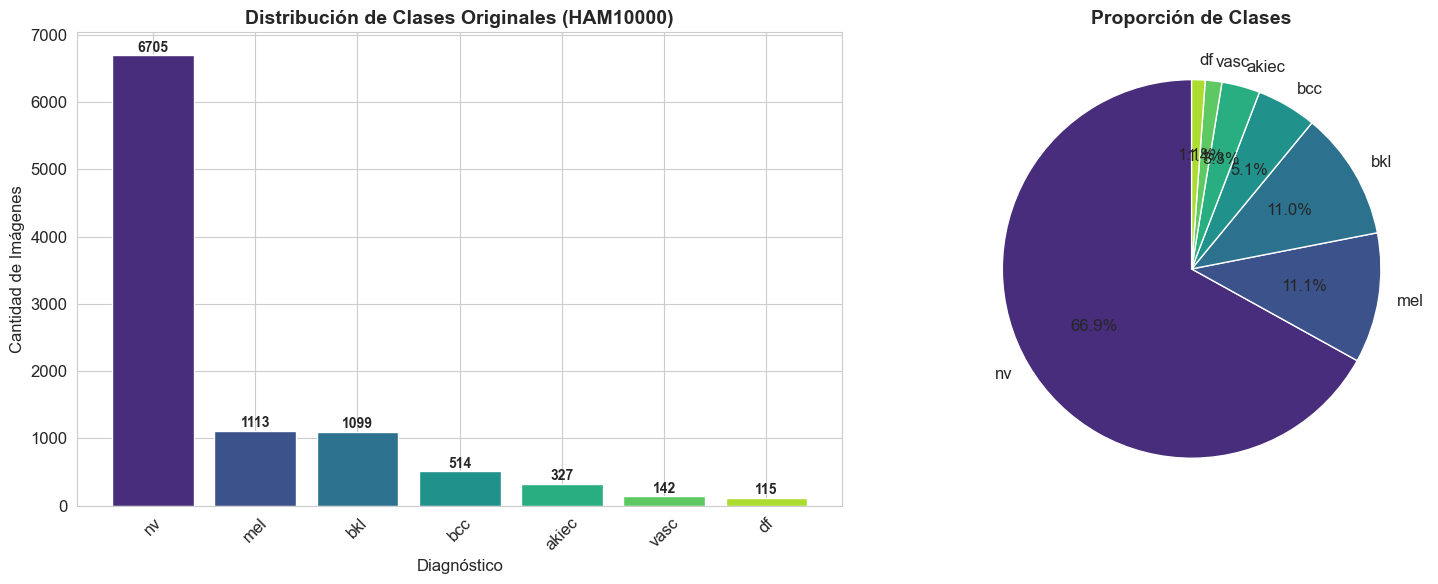


Distribución de clases:
  nv: 6705 (66.9%)
  mel: 1113 (11.1%)
  bkl: 1099 (11.0%)
  bcc: 514 (5.1%)
  akiec: 327 (3.3%)
  vasc: 142 (1.4%)
  df: 115 (1.1%)


In [143]:
# ============================================
# DISTRIBUCIÓN DE CLASES ORIGINALES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Conteo por clase
class_counts = df['dx'].value_counts()
colors = sns.color_palette('viridis', len(class_counts))

# Bar plot
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Distribución de Clases Originales (HAM10000)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnóstico', fontsize=12)
axes[0].set_ylabel('Cantidad de Imágenes', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 50, str(val), ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'class_distribution_original.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nDistribución de clases:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count} ({count/len(df)*100:.1f}%)')

### 4.2 Clasificación Binaria (Benigno vs Maligno)

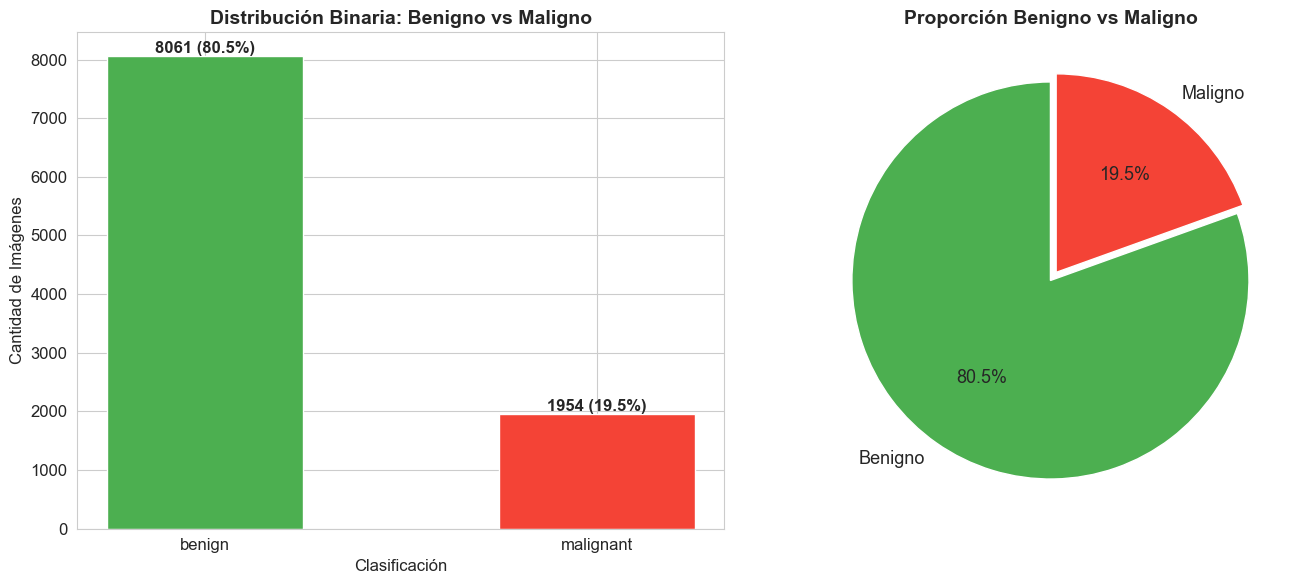


Benigno: 8061 imágenes (80.5%)
Maligno: 1954 imágenes (19.5%)

Ratio Benigno/Maligno: 4.13:1


In [144]:
# ============================================
# MAPEO A CLASIFICACIÓN BINARIA
# ============================================

LABEL_MAP = {
    'nv': 'benign',
    'bkl': 'benign',
    'df': 'benign',
    'vasc': 'benign',
    'mel': 'malignant',
    'bcc': 'malignant',
    'akiec': 'malignant',
}

df['binary_label'] = df['dx'].map(LABEL_MAP)

# Distribución binaria
binary_counts = df['binary_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
colors_binary = ['#4CAF50', '#F44336']
axes[0].bar(binary_counts.index, binary_counts.values, color=colors_binary, width=0.5)
axes[0].set_title('Distribución Binaria: Benigno vs Maligno', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clasificación', fontsize=12)
axes[0].set_ylabel('Cantidad de Imágenes', fontsize=12)
for i, (idx, val) in enumerate(zip(binary_counts.index, binary_counts.values)):
    axes[0].text(i, val + 50, f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(binary_counts.values, labels=['Benigno', 'Maligno'], autopct='%1.1f%%',
            colors=colors_binary, startangle=90, textprops={'fontsize': 13},
            explode=(0, 0.05))
axes[1].set_title('Proporción Benigno vs Maligno', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'class_distribution_binary.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBenigno: {binary_counts["benign"]} imágenes ({binary_counts["benign"]/len(df)*100:.1f}%)')
print(f'Maligno: {binary_counts["malignant"]} imágenes ({binary_counts["malignant"]/len(df)*100:.1f}%)')
print(f'\nRatio Benigno/Maligno: {binary_counts["benign"]/binary_counts["malignant"]:.2f}:1')

### 4.3 Visualización de Imágenes de Ejemplo

Directorios con imágenes: ['C:\\Users\\Sebas\\.cache\\kagglehub\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_part_1', 'C:\\Users\\Sebas\\.cache\\kagglehub\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_part_2']


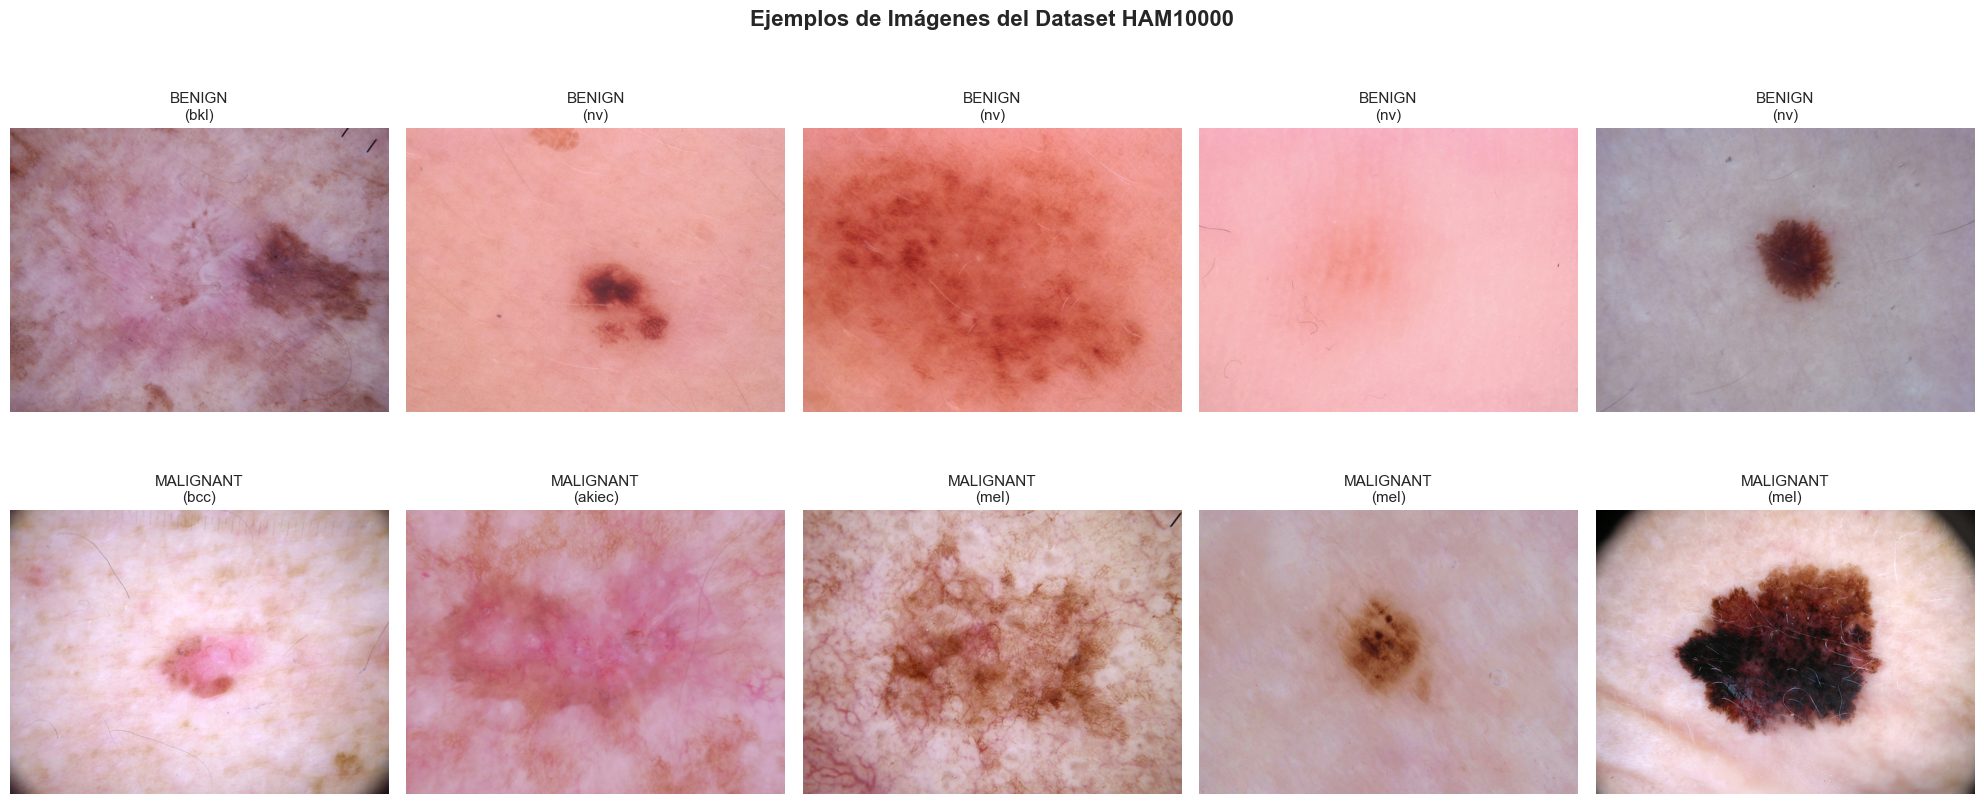

In [145]:
# ============================================
# VISUALIZACIÓN DE IMÁGENES DE EJEMPLO
# ============================================

# Buscar directorio con imágenes
image_dirs = []
for root, dirs, files in os.walk(dataset_path):
    jpg_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(jpg_files) > 10:
        image_dirs.append(root)

print(f'Directorios con imágenes: {image_dirs}')

# Mostrar ejemplos de cada clase
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Ejemplos de Imágenes del Dataset HAM10000', fontsize=16, fontweight='bold')

for row, label in enumerate(['benign', 'malignant']):
    label_df = df[df['binary_label'] == label].sample(5, random_state=SEED)
    for col, (_, row_data) in enumerate(label_df.iterrows()):
        img_id = row_data['image_id']
        # Buscar imagen
        img_found = False
        for img_dir in image_dirs:
            for ext in ['.jpg', '.jpeg', '.png']:
                img_path = os.path.join(img_dir, f'{img_id}{ext}')
                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    axes[row, col].imshow(img)
                    axes[row, col].set_title(f'{label.upper()}\n({row_data["dx"]})', fontsize=11)
                    axes[row, col].axis('off')
                    img_found = True
                    break
            if img_found:
                break

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Análisis Exploratorio Adicional

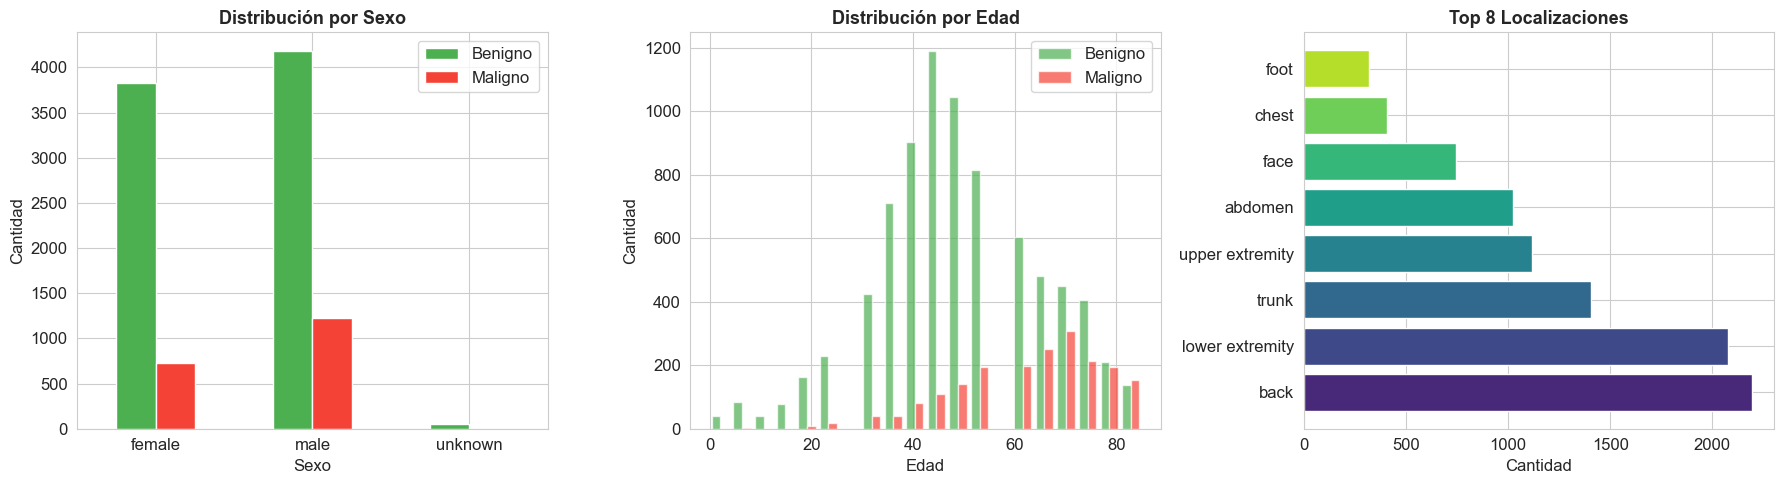

In [146]:
# ============================================
# ANÁLISIS POR EDAD, SEXO Y LOCALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución por sexo
if 'sex' in df.columns:
    sex_label = df.groupby(['sex', 'binary_label']).size().unstack(fill_value=0)
    sex_label.plot(kind='bar', ax=axes[0], color=colors_binary)
    axes[0].set_title('Distribución por Sexo', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Sexo')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(['Benigno', 'Maligno'])

# Distribución por edad
if 'age' in df.columns:
    df_age = df.dropna(subset=['age'])
    axes[1].hist([df_age[df_age['binary_label']=='benign']['age'],
                  df_age[df_age['binary_label']=='malignant']['age']],
                 bins=20, color=colors_binary, label=['Benigno', 'Maligno'], alpha=0.7)
    axes[1].set_title('Distribución por Edad', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Edad')
    axes[1].set_ylabel('Cantidad')
    axes[1].legend()

# Distribución por localización
if 'localization' in df.columns:
    top_loc = df['localization'].value_counts().head(8)
    axes[2].barh(top_loc.index, top_loc.values, color=sns.color_palette('viridis', 8))
    axes[2].set_title('Top 8 Localizaciones', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Cantidad')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'eda_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocesamiento de Datos

### 5.1 Organización del Dataset

Organizamos las imágenes en carpetas según su clasificación binaria (benign/malignant) para facilitar el uso de `ImageDataGenerator`.

In [147]:
# ============================================
# ORGANIZAR IMÁGENES EN CARPETAS
# ============================================

# Crear directorios para cada clase
for label in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_DIR, label), exist_ok=True)

# Copiar imágenes organizadas por clase
print('Organizando imágenes por clase...')
copied = 0
not_found = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Organizando'):
    image_id = row['image_id']
    label = row['binary_label']
    
    # Buscar la imagen en los directorios
    found = False
    for img_dir in image_dirs:
        for ext in ['.jpg', '.jpeg', '.png']:
            src_path = os.path.join(img_dir, f'{image_id}{ext}')
            if os.path.exists(src_path):
                dst_path = os.path.join(PROCESSED_DIR, label, f'{image_id}{ext}')
                if not os.path.exists(dst_path):
                    shutil.copy2(src_path, dst_path)
                copied += 1
                found = True
                break
        if found:
            break
    if not found:
        not_found += 1

print(f'\nImágenes copiadas: {copied}')
print(f'Imágenes no encontradas: {not_found}')

# Verificar conteo
for label in CLASS_NAMES:
    label_dir = os.path.join(PROCESSED_DIR, label)
    count = len(os.listdir(label_dir))
    print(f'  {label}: {count} imágenes')

Organizando imágenes por clase...


Organizando: 100%|██████████| 10015/10015 [00:04<00:00, 2192.56it/s]


Imágenes copiadas: 10015
Imágenes no encontradas: 0
  benign: 8061 imágenes
  malignant: 1954 imágenes


### 5.2 Validación de Imágenes (Eliminación de Corruptas)

In [148]:
# ============================================
# VALIDACIÓN DE IMÁGENES
# ============================================

print('Validando integridad de imágenes...')
total_images = 0
corrupted_images = 0
valid_images = 0

for label in CLASS_NAMES:
    label_dir = os.path.join(PROCESSED_DIR, label)
    for filename in tqdm(os.listdir(label_dir), desc=f'Validando {label}'):
        filepath = os.path.join(label_dir, filename)
        total_images += 1
        try:
            img = Image.open(filepath)
            img.verify()
            valid_images += 1
        except Exception:
            corrupted_images += 1
            os.remove(filepath)
            print(f'  [ELIMINADA] {filepath}')

print(f'\nResultado de validación:')
print(f'  Total imágenes: {total_images}')
print(f'  Válidas: {valid_images}')
print(f'  Corruptas eliminadas: {corrupted_images}')

Validando integridad de imágenes...


Validando malignant: 100%|██████████| 1954/1954 [00:00<00:00, 5646.68it/s]


Resultado de validación:
  Total imágenes: 10015
  Válidas: 10015
  Corruptas eliminadas: 0


### 5.3 División del Dataset (Train / Validation / Test)

Dividimos el dataset en tres conjuntos:
- **Train (70%):** Para entrenar el modelo
- **Validation (15%):** Para monitorear durante el entrenamiento
- **Test (15%):** Para evaluación final independiente

In [149]:
# ============================================
# DIVISIÓN DEL DATASET: 70% / 15% / 15%
# ============================================

SPLIT_DIR = os.path.join(DATA_DIR, 'split')

print('Dividiendo dataset en Train/Validation/Test...')
print(f'  Ratio: 70% train, 15% validation, 15% test')
print(f'  Seed: {SEED}')

splitfolders.ratio(
    PROCESSED_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None,
    move=False
)

# Actualizar rutas a los splits generados
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DIR, 'test')

# Contar imágenes por split
print('\nDistribución final:')
print('-' * 40)
for split_name, split_dir in [('Train', TRAIN_DIR), ('Validation', VAL_DIR), ('Test', TEST_DIR)]:
    total = 0
    for label in CLASS_NAMES:
        label_path = os.path.join(split_dir, label)
        if os.path.exists(label_path):
            count = len(os.listdir(label_path))
            total += count
            print(f'  {split_name}/{label}: {count}')
    print(f'  {split_name} TOTAL: {total}')
    print()

Dividiendo dataset en Train/Validation/Test...
  Ratio: 70% train, 15% validation, 15% test
  Seed: 42


Copying files: 10015 files [00:32, 309.96 files/s]


Distribución final:
----------------------------------------
  Train/benign: 5642
  Train/malignant: 1367
  Train TOTAL: 7009

  Validation/benign: 1209
  Validation/malignant: 293
  Validation TOTAL: 1502

  Test/benign: 1210
  Test/malignant: 294
  Test TOTAL: 1504



### 5.4 Data Augmentation y Generadores de Datos

Aplicamos **Data Augmentation** al conjunto de entrenamiento para:
- Aumentar la diversidad de datos
- Reducir overfitting
- Mejorar la generalización del modelo

**Transformaciones aplicadas:**
- Rotación: ±20°
- Zoom: ±20%
- Flip horizontal
- Desplazamiento horizontal/vertical: ±20%
- Normalización: [0, 1]

In [150]:
# ============================================
# DATA AUGMENTATION Y GENERADORES
# ============================================

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.efficientnet import preprocess_input
import shutil as _shutil

# -------------------------------------------------------
# PASO CLAVE: Sobremuestrear clase MALIGNA en train
# Copiamos imágenes malignas varias veces con augmentation
# para que el modelo vea ambas clases de forma balanceada
# -------------------------------------------------------

train_benign_dir = os.path.join(TRAIN_DIR, 'benign')
train_malignant_dir = os.path.join(TRAIN_DIR, 'malignant')

n_benign = len(os.listdir(train_benign_dir))
n_malignant = len(os.listdir(train_malignant_dir))
print(f'Antes de oversampling:')
print(f'  Benign: {n_benign}')
print(f'  Malignant: {n_malignant}')
print(f'  Ratio: {n_benign/n_malignant:.1f}:1')

# Duplicar imágenes malignas hasta igualar benignas
if n_malignant < n_benign:
    malignant_files = os.listdir(train_malignant_dir)
    copies_needed = n_benign - n_malignant
    for i in range(copies_needed):
        src_file = malignant_files[i % len(malignant_files)]
        src_path = os.path.join(train_malignant_dir, src_file)
        name, ext = os.path.splitext(src_file)
        dst_path = os.path.join(train_malignant_dir, f'{name}_dup{i}{ext}')
        if not os.path.exists(dst_path):
            _shutil.copy2(src_path, dst_path)

n_malignant_new = len(os.listdir(train_malignant_dir))
print(f'\nDespues de oversampling:')
print(f'  Benign: {n_benign}')
print(f'  Malignant: {n_malignant_new}')
print(f'  Ratio: {n_benign/n_malignant_new:.1f}:1')

# -------------------------------------------------------
# VISUALIZACION DEL BALANCEO DE CLASES
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del oversampling
labels_before = ['Benign', 'Malignant']
counts_before = [n_benign, n_malignant]
colors = ['#4CAF50', '#F44336']

axes[0].bar(labels_before, counts_before, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
axes[0].set_title('ANTES del Oversampling', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de imagenes', fontsize=12)
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts_before) * 1.15)

# Despues del oversampling
counts_after = [n_benign, n_malignant_new]

axes[1].bar(labels_before, counts_after, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
axes[1].set_title('DESPUES del Oversampling (Balanceado)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad de imagenes', fontsize=12)
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(counts_after) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'class_balance_oversampling.png'), dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
balance_df = pd.DataFrame({
    'Clase': ['Benign', 'Malignant'],
    'Antes': counts_before,
    'Despues': counts_after,
    'Diferencia': [counts_after[0]-counts_before[0], counts_after[1]-counts_before[1]]
})
print('\n')
print(balance_df.to_string(index=False))
print(f'\nClases balanceadas exitosamente para entrenamiento.')

# -------------------------------------------------------
# GENERADORES con augmentation agresiva para train
# -------------------------------------------------------

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Class weights adicionales (ahora mas suaves porque ya balanceamos)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

print(f'\nGeneradores creados:')
print(f'  Train: {train_generator.samples} imagenes (balanceado)')
print(f'  Validation: {val_generator.samples} imagenes')
print(f'  Test: {test_generator.samples} imagenes')
print(f'  Class weights: {class_weight_dict}')

Found 7009 images belonging to 2 classes.
Found 1502 images belonging to 2 classes.
Found 1504 images belonging to 2 classes.

Resumen de generadores:
  Train: 7009 imagenes
  Validation: 1502 imagenes
  Test: 1504 imagenes
  Clases: {'benign': 0, 'malignant': 1}

  CLASS WEIGHTS:
    Clase 0 (benign): 0.6211
    Clase 1 (malignant): 2.5636


### 5.5 Visualización de Data Augmentation

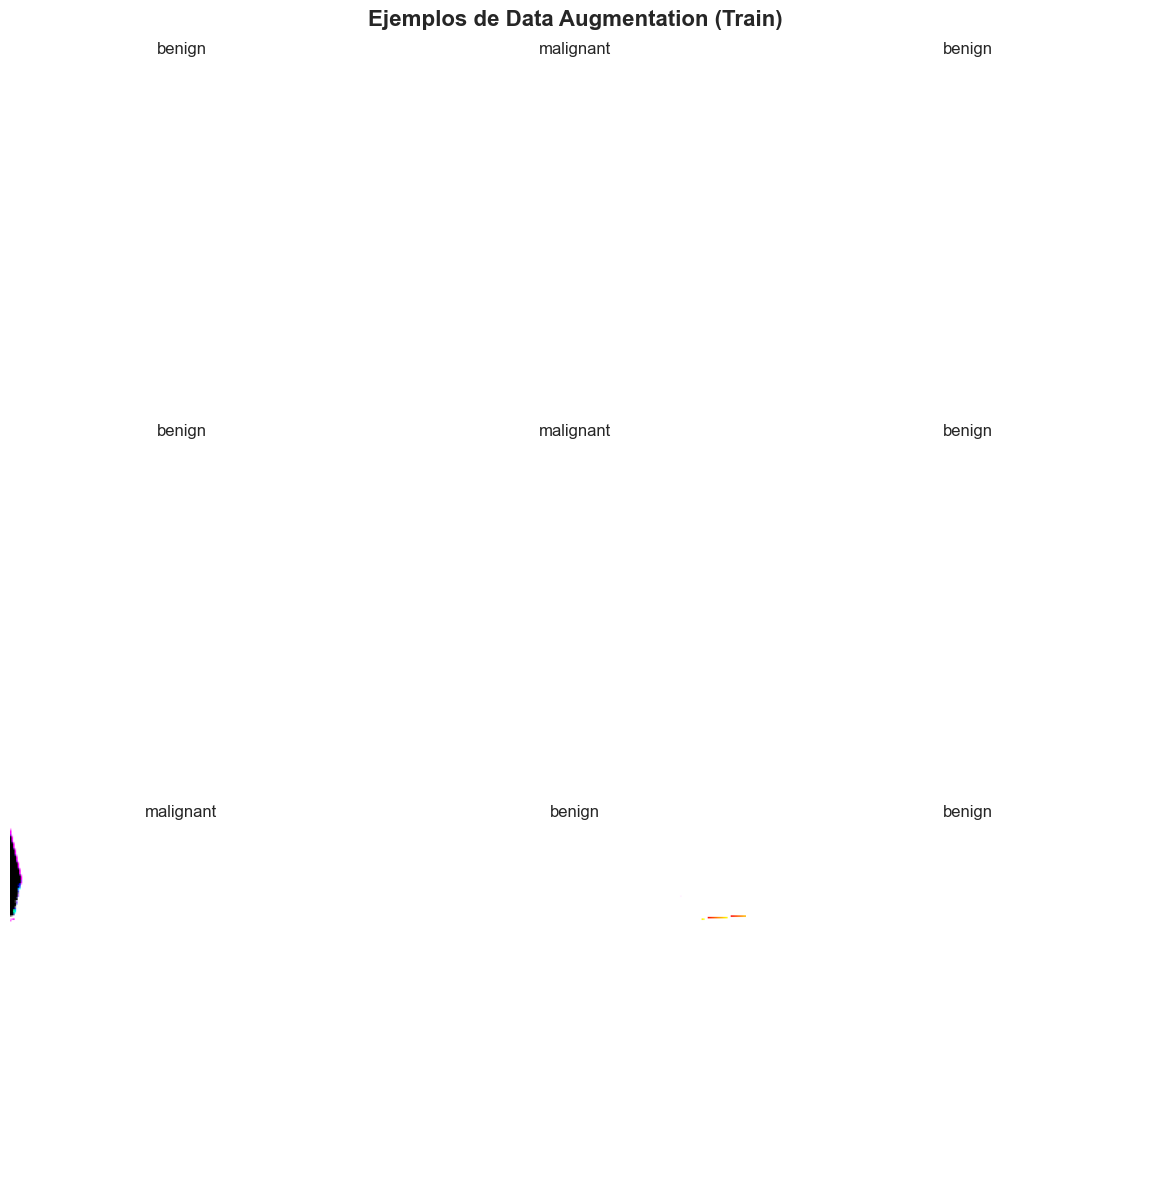

In [151]:
# ============================================
# VISUALIZAR DATA AUGMENTATION
# ============================================

# Tomar una imagen de ejemplo
sample_batch = next(iter(train_generator))
sample_images = sample_batch[0][:9]
sample_labels = sample_batch[1][:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Ejemplos de Data Augmentation (Train)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        ax.imshow(sample_images[i])
        label_idx = np.argmax(sample_labels[i])
        ax.set_title(f'{CLASS_NAMES[label_idx]}', fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'data_augmentation_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Construcción del Modelo CNN

### 6.1 Arquitectura: Transfer Learning con EfficientNetB0

**¿Por qué Transfer Learning?**
- Aprovecha features aprendidos de millones de imágenes (ImageNet)
- Reduce significativamente el tiempo de entrenamiento
- Mejora el rendimiento con datasets pequeños/medianos
- EfficientNetB0 ofrece excelente balance entre accuracy y eficiencia

**Arquitectura del modelo:**
```
Input (224, 224, 3)
    → EfficientNetB0 (pre-trained, frozen)
    → GlobalAveragePooling2D
    → Dropout(0.3)
    → Dense(128, ReLU)
    → Dense(2, Softmax)
```

In [152]:
# ============================================
# CONSTRUCCION DEL MODELO CNN
# ============================================

from tensorflow.keras.applications import MobileNetV2

print('Construyendo modelo con Transfer Learning (MobileNetV2)...')
print('=' * 60)

# Modelo base pre-entrenado en ImageNet
# MobileNetV2 funciona con imagenes en rango [0, 1]
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# FASE 1: Congelar modelo base completo
base_model.trainable = False

# Construir clasificador
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

# Compilar
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\nModelo construido exitosamente.')
print(f'Total parametros: {model.count_params():,}')
trainable = sum(p.numpy().size for p in model.trainable_weights)
non_trainable = sum(p.numpy().size for p in model.non_trainable_weights)
print(f'Parametros entrenables: {trainable:,}')
print(f'Parametros NO entrenables (congelados): {non_trainable:,}')
print(f'\nFASE 1: Solo se entrena el clasificador (capas densas)')

Construyendo modelo con Transfer Learning (EfficientNetB0)...

Modelo construido exitosamente.
Total parametros: 4,213,797
Parametros entrenables: 164,226
Parametros NO entrenables (congelados): 4,049,571

FASE 1: Solo se entrena el clasificador (capas densas)


In [153]:
# ============================================
# RESUMEN DEL MODELO
# ============================================

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,797 (16.07 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 6.2 Configuración de Callbacks

- **EarlyStopping:** Detiene el entrenamiento si val_loss no mejora en 5 épocas
- **ReduceLROnPlateau:** Reduce el learning rate si val_loss se estanca
- **ModelCheckpoint:** Guarda el mejor modelo según val_accuracy

In [154]:
# ============================================
# CONFIGURACIÓN DE CALLBACKS
# ============================================

MODEL_PATH = os.path.join(MODELS_DIR, 'best_model.h5')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Callbacks configurados:')
print(f'  - EarlyStopping (patience=7, monitor=val_loss)')
print(f'  - ReduceLROnPlateau (factor=0.5, patience=3)')
print(f'  - ModelCheckpoint -> {MODEL_PATH}')

Callbacks configurados:
  - EarlyStopping (patience=7, monitor=val_loss)
  - ReduceLROnPlateau (factor=0.5, patience=3)
  - ModelCheckpoint -> c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5


## 7. Entrenamiento del Modelo

### 7.1 Fase 1: Feature Extraction (clasificador)

Primero entrenamos solo las capas densas del clasificador con el modelo base congelado. Esto permite que el clasificador aprenda a usar los features de ImageNet para nuestro problema específico.

In [155]:
# ============================================
# FASE 1: ENTRENAR CLASIFICADOR (base congelada)
# ============================================

print('FASE 1: Entrenando clasificador (EfficientNetB0 congelado)')
print(f'  Epocas: 10')
print(f'  Learning rate: 1e-3')
print(f'  Clases balanceadas por oversampling - sin class_weight')
print('=' * 60)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

history_phase1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

print('\nFASE 1 COMPLETADA')
print(f'  val_accuracy: {max(history_phase1.history["val_accuracy"]):.4f}')

FASE 1: Entrenando clasificador (EfficientNetB0 congelado)
  Epocas: 10
  Learning rate: 1e-3
  Class weights: {0: np.float64(0.6211449840482098), 1: np.float64(2.563643013899049)}
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.7089 - loss: 0.5245 - val_accuracy: 0.7530 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 185s 843ms/step - accuracy: 0.7332 - loss: 0.4582 - val_accuracy: 0.7623 - val_loss: 0.4388 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 189s 858ms/step - accuracy: 0.7382 - loss: 0.4524 - val_accuracy: 0.8142 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 197s 895ms/step - accuracy: 0.7369 - loss: 0.4431 - val_accuracy: 0.7716 - val_loss: 0.4396 - learning_rate: 0.0010
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.7529 - loss: 0.4293
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 214s 

### 7.2 Fase 2: Fine-Tuning (descongelar modelo base)

Ahora descongelamos el modelo base completo y entrenamos con un learning rate 10x menor para ajustar los features sin destruir los pesos pre-entrenados.

In [156]:
# ============================================
# FASE 2: FINE-TUNING (descongelar ultimas capas)
# ============================================

print('FASE 2: Fine-Tuning')
print('=' * 60)

# Descongelar solo las ultimas 50 capas
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompilar con lr bajo
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(p.numpy().size for p in model.trainable_weights)
print(f'  Parametros entrenables: {trainable:,}')
print(f'  Learning rate: 1e-4')

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_phase2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

print('\n' + '=' * 60)
print('ENTRENAMIENTO COMPLETADO')
print('=' * 60)
print(f'Mejor val_accuracy: {max(history_phase2.history["val_accuracy"]):.4f}')
print(f'Mejor val_loss: {min(history_phase2.history["val_loss"]):.4f}')

FASE 2: Fine-Tuning (descongelando EfficientNetB0)
  Parametros entrenables ahora: 4,171,774
  Learning rate: 1e-5
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6449 - loss: 0.6465
Epoch 1: val_accuracy improved from None to 0.78695, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 1: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 625s 3s/step - accuracy: 0.6606 - loss: 0.6002 - val_accuracy: 0.7870 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7052 - loss: 0.5136
Epoch 2: val_accuracy did not improve from 0.78695
220/220 ━━━━━━━━━━━━━━━━━━━━ 583s 3s/step - accuracy: 0.7158 - loss: 0.5083 - val_accuracy: 0.7796 - val_loss: 0.4379 - learning_rate: 1.0000e-05
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7245 - loss: 0.4839
Epoch 3: val_accuracy did not improve from 0.78695
220/220 ━━━━━━━━━━━━━━━━━━━━ 567s 3s/step - accuracy: 0.7265 - loss: 0.4862 - val_accuracy: 0.7850 - val_loss: 0.4216 - learning_rate: 1.0000e-05
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7406 - loss: 0.4650
Epoch 4: val_accuracy did not improve from 0.78695
220/220 ━━━━━━━━━━━━━━━━━━━━ 553s 3s/ste


Epoch 5: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 605s 3s/step - accuracy: 0.7490 - loss: 0.4458 - val_accuracy: 0.7916 - val_loss: 0.4092 - learning_rate: 1.0000e-05
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7570 - loss: 0.4233
Epoch 6: val_accuracy improved from 0.79161 to 0.79627, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 6: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 585s 3s/step - accuracy: 0.7602 - loss: 0.4255 - val_accuracy: 0.7963 - val_loss: 0.3937 - learning_rate: 1.0000e-05
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7569 - loss: 0.4381
Epoch 7: val_accuracy improved from 0.79627 to 0.79760, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 7: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 774s 4s/step - accuracy: 0.7673 - loss: 0.4242 - val_accuracy: 0.7976 - val_loss: 0.3895 - learning_rate: 1.0000e-05
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7761 - loss: 0.4129
Epoch 8: val_accuracy improved from 0.79760 to 0.80226, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 8: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.7771 - loss: 0.4106 - val_accuracy: 0.8023 - val_loss: 0.3785 - learning_rate: 1.0000e-05
Epoch 9/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7804 - loss: 0.4041
Epoch 9: val_accuracy improved from 0.80226 to 0.80626, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 9: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.7824 - loss: 0.3959 - val_accuracy: 0.8063 - val_loss: 0.3716 - learning_rate: 1.0000e-05
Epoch 10/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7914 - loss: 0.3849
Epoch 10: val_accuracy improved from 0.80626 to 0.81358, saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5



Epoch 10: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.7911 - loss: 0.3796 - val_accuracy: 0.8136 - val_loss: 0.3636 - learning_rate: 1.0000e-05
Epoch 11/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7987 - loss: 0.3795
Epoch 11: val_accuracy did not improve from 0.81358
220/220 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7973 - loss: 0.3860 - val_accuracy: 0.8096 - val_loss: 0.3730 - learning_rate: 1.0000e-05
Epoch 12/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7968 - loss: 0.3688
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 12: val_accuracy did not improve from 0.81358
220/220 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.7977 - loss: 0.3727 - val_accuracy: 0.8096 - val_loss: 0.3750 - learning_rate: 1.0000e-05
Epoch 13/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8061 - loss: 0.3737
Epoch 1


Epoch 15: finished saving model to c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
220/220 ━━━━━━━━━━━━━━━━━━━━ 844s 4s/step - accuracy: 0.8085 - loss: 0.3605 - val_accuracy: 0.8182 - val_loss: 0.3648 - learning_rate: 2.5000e-06
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.

ENTRENAMIENTO COMPLETADO (Fase 1 + Fase 2)
Mejor val_accuracy: 0.8182
Mejor val_loss: 0.3636


### 7.2 Gráficas de Entrenamiento (Accuracy y Loss)

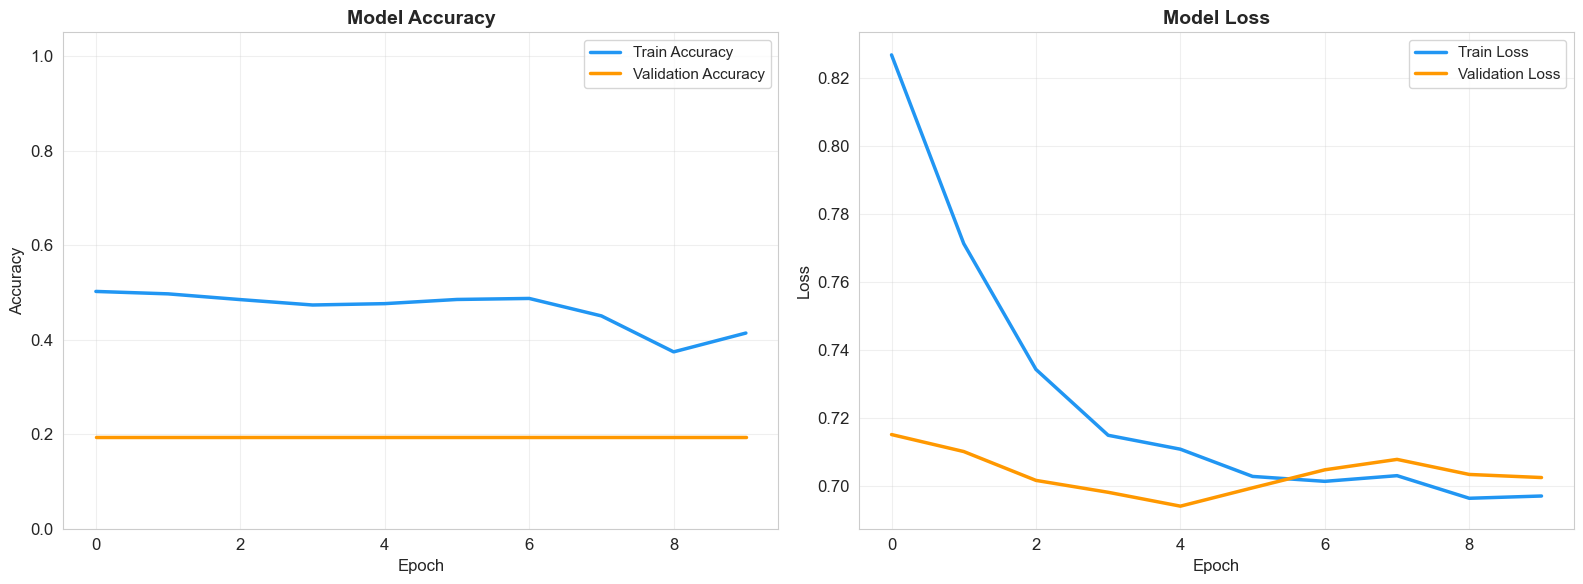

Grafica de entrenamiento guardada.


In [157]:
# ============================================
# GRAFICAS DE ENTRENAMIENTO
# ============================================

# Combinar historiales de ambas fases
full_acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
full_val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
full_loss = history_phase1.history['loss'] + history_phase2.history['loss']
full_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
phase1_end = len(history_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(full_acc, label='Train Accuracy', linewidth=2.5, color='#2196F3')
axes[0].plot(full_val_acc, label='Validation Accuracy', linewidth=2.5, color='#FF9800')
axes[0].axvline(x=phase1_end, color='red', linestyle='--', alpha=0.7, label='Fine-tuning start')
axes[0].set_title('Model Accuracy (Fase 1 + Fine-Tuning)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss
axes[1].plot(full_loss, label='Train Loss', linewidth=2.5, color='#2196F3')
axes[1].plot(full_val_loss, label='Validation Loss', linewidth=2.5, color='#FF9800')
axes[1].axvline(x=phase1_end, color='red', linestyle='--', alpha=0.7, label='Fine-tuning start')
axes[1].set_title('Model Loss (Fase 1 + Fine-Tuning)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training', 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Grafica de entrenamiento guardada.')

### 7.4 Guardar Modelo Entrenado

In [158]:
# ============================================
# GUARDAR MODELO
# ============================================

# Guardar modelo final
final_model_path = os.path.join(MODELS_DIR, 'skin_cancer_model.h5')
model.save(final_model_path)
print(f'Modelo guardado en: {final_model_path}')

# Verificar que el mejor modelo existe
if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
    print(f'Mejor modelo (checkpoint): {MODEL_PATH} ({size_mb:.1f} MB)')

# Cargar el mejor modelo para evaluación
model = tf.keras.models.load_model(MODEL_PATH)
print('\nMejor modelo cargado para evaluación.')

Modelo guardado en: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\skin_cancer_model.h5
Mejor modelo (checkpoint): c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5 (48.6 MB)



Mejor modelo cargado para evaluación.


## 8. Evaluación Completa del Modelo

Evaluamos el modelo en los tres conjuntos de datos:
- **TRAIN:** Para verificar que el modelo aprendió correctamente
- **VALIDATION:** Para verificar generalización durante entrenamiento
- **TEST:** Evaluación final independiente (datos nunca vistos)

Para cada conjunto generamos:
- Accuracy, Precision, Recall, F1-Score
- Classification Report completo
- Matriz de Confusión (heatmap)
- Curva ROC con AUC

### 8.1 Función de Evaluación Completa

In [159]:
# ============================================
# FUNCIÓN DE EVALUACIÓN COMPLETA
# ============================================

def evaluate_generator(model, generator, split_name, class_names, results_dir):
    """
    Evaluación completa de un split con todas las métricas.
    
    Returns: dict con todas las métricas
    """
    print(f'\n{"="*60}')
    print(f'  EVALUACIÓN: {split_name.upper()}')
    print(f'{"="*60}')
    
    # Obtener predicciones
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = generator.classes
    
    # Calcular métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Mostrar métricas
    print(f'\n  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    
    # Classification Report
    print(f'\n  Classification Report ({split_name.upper()}):')
    print('-' * 50)
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_score': f1, 'roc_auc': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'cm': cm,
        'y_true': y_true, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

print('Función de evaluación definida.')

Función de evaluación definida.


### 8.2 Evaluación en TRAIN

In [35]:
# ============================================
# EVALUACIÓN EN TRAIN
# ============================================

# Crear generador limpio para evaluar train (sin augmentation, sin shuffle)
train_eval_datagen = ImageDataGenerator(rescale=1./255)
train_eval_generator = train_eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Evaluar directamente
print('\nEvaluando en TRAIN...')
train_eval_generator.reset()
y_pred_proba_train = model.predict(train_eval_generator, verbose=1)
y_pred_train = np.argmax(y_pred_proba_train, axis=1)
y_true_train = train_eval_generator.classes[:len(y_pred_train)]

print(f'\nVerificacion:')
print(f'  Predicciones shape: {y_pred_proba_train.shape}')
print(f'  y_true length: {len(y_true_train)}')
print(f'  y_pred unique: {np.unique(y_pred_train, return_counts=True)}')
print(f'  y_true unique: {np.unique(y_true_train, return_counts=True)}')

metrics_train = evaluate_generator(model, train_eval_generator, 'train', CLASS_NAMES, RESULTS_DIR)

Found 11284 images belonging to 2 classes.

Evaluando en TRAIN...
353/353 [==============================] - 132s 374ms/step

Verificacion:
  Predicciones shape: (11284, 2)
  y_true length: 11284
  y_pred unique: (array([0, 1], dtype=int64), array([6005, 5279], dtype=int64))
  y_true unique: (array([0, 1]), array([5642, 5642], dtype=int64))

  EVALUACIÓN: TRAIN
353/353 [==============================] - 114s 324ms/step

  Accuracy:  0.8544
  Precision: 0.8559
  Recall:    0.8544
  F1-Score:  0.8542
  ROC-AUC:   0.9436

  Classification Report (TRAIN):
--------------------------------------------------
              precision    recall  f1-score   support

      benign       0.83      0.89      0.86      5642
   malignant       0.88      0.82      0.85      5642

    accuracy                           0.85     11284
   macro avg       0.86      0.85      0.85     11284
weighted avg       0.86      0.85      0.85     11284



### 8.3 Evaluación en VALIDATION

In [161]:
# ============================================
# EVALUACIÓN EN VALIDATION
# ============================================

metrics_val = evaluate_generator(model, val_generator, 'validation', CLASS_NAMES, RESULTS_DIR)


  EVALUACIÓN: VALIDATION
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 352ms/step

  Accuracy:  0.8475
  Precision: 0.8333
  Recall:    0.8475
  F1-Score:  0.8337
  ROC-AUC:   0.8360

  Classification Report (VALIDATION):
--------------------------------------------------
              precision    recall  f1-score   support

      benign       0.87      0.95      0.91      1209
   malignant       0.67      0.43      0.52       293

    accuracy                           0.85      1502
   macro avg       0.77      0.69      0.72      1502
weighted avg       0.83      0.85      0.83      1502



### 8.4 Evaluación en TEST

In [162]:
# ============================================
# EVALUACIÓN EN TEST
# ============================================

metrics_test = evaluate_generator(model, test_generator, 'test', CLASS_NAMES, RESULTS_DIR)


  EVALUACIÓN: TEST
47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 684ms/step

  Accuracy:  0.8464
  Precision: 0.8316
  Recall:    0.8464
  F1-Score:  0.8312
  ROC-AUC:   0.8496

  Classification Report (TEST):
--------------------------------------------------
              precision    recall  f1-score   support

      benign       0.87      0.95      0.91      1210
   malignant       0.68      0.41      0.51       294

    accuracy                           0.85      1504
   macro avg       0.77      0.68      0.71      1504
weighted avg       0.83      0.85      0.83      1504



## 9. Matrices de Confusión

Las matrices de confusión muestran la distribución de predicciones correctas e incorrectas para cada clase.

### 9.1 Matriz de Confusión - TRAIN

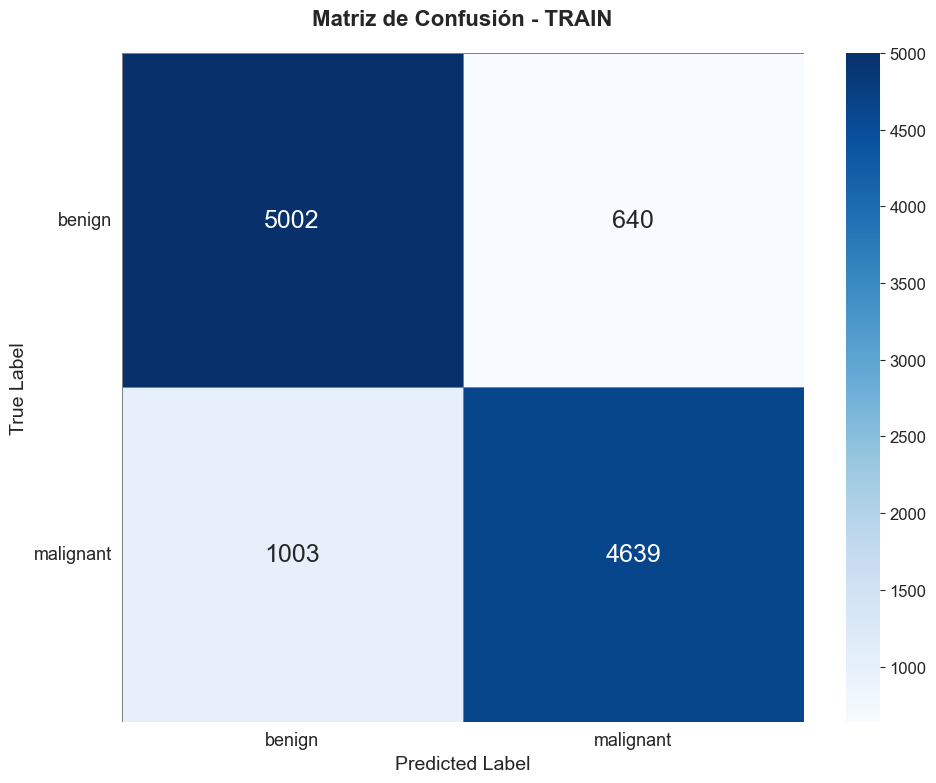

In [36]:
# ============================================
# MATRIZ DE CONFUSIÓN - TRAIN
# ============================================

plt.figure(figsize=(10, 8))
sns.heatmap(
    metrics_train['cm'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 18},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Matriz de Confusión - TRAIN', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix', 'confusion_matrix_train.png'), dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Matriz de Confusión - VALIDATION

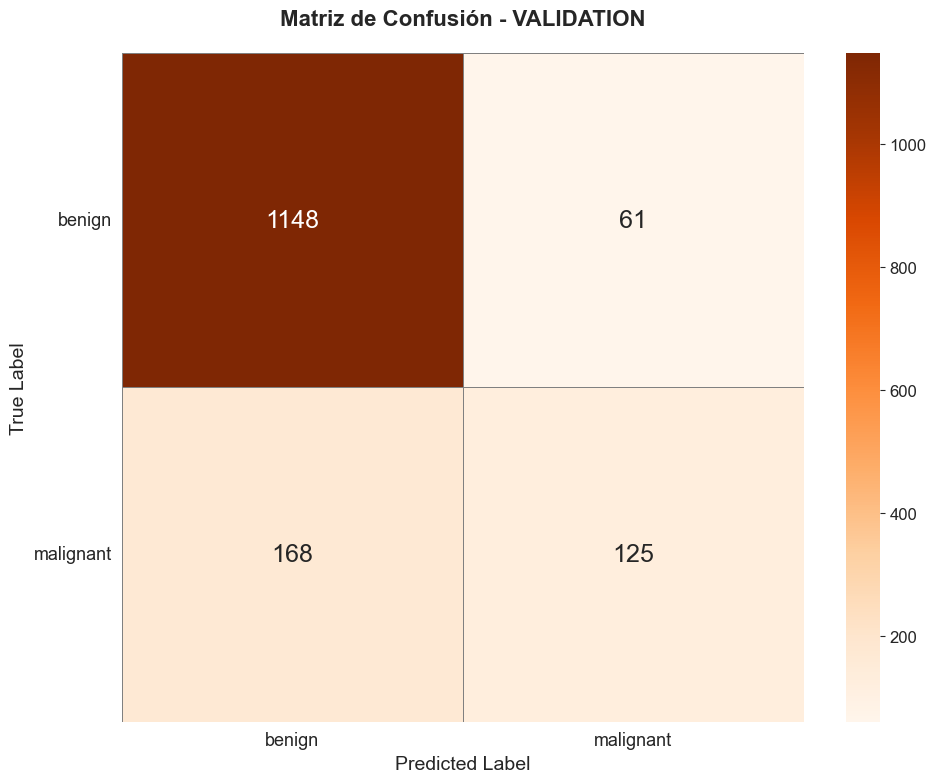

In [164]:
# ============================================
# MATRIZ DE CONFUSIÓN - VALIDATION
# ============================================

plt.figure(figsize=(10, 8))
sns.heatmap(
    metrics_val['cm'],
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 18},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Matriz de Confusión - VALIDATION', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix', 'confusion_matrix_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Matriz de Confusión - TEST

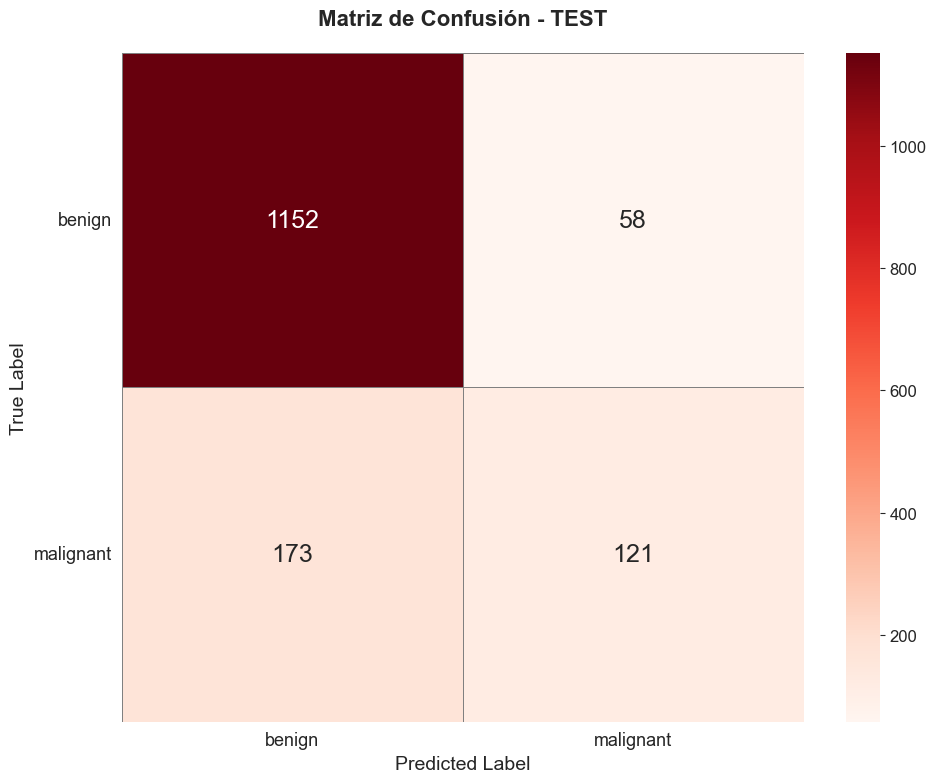

In [165]:
# ============================================
# MATRIZ DE CONFUSIÓN - TEST
# ============================================

plt.figure(figsize=(10, 8))
sns.heatmap(
    metrics_test['cm'],
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 18},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Matriz de Confusión - TEST', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix', 'confusion_matrix_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Curvas ROC (Receiver Operating Characteristic)

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Sensitivity) y la tasa de falsos positivos (1-Specificity). El AUC (Area Under Curve) indica la capacidad discriminativa del modelo.

### 10.1 Curva ROC - TRAIN

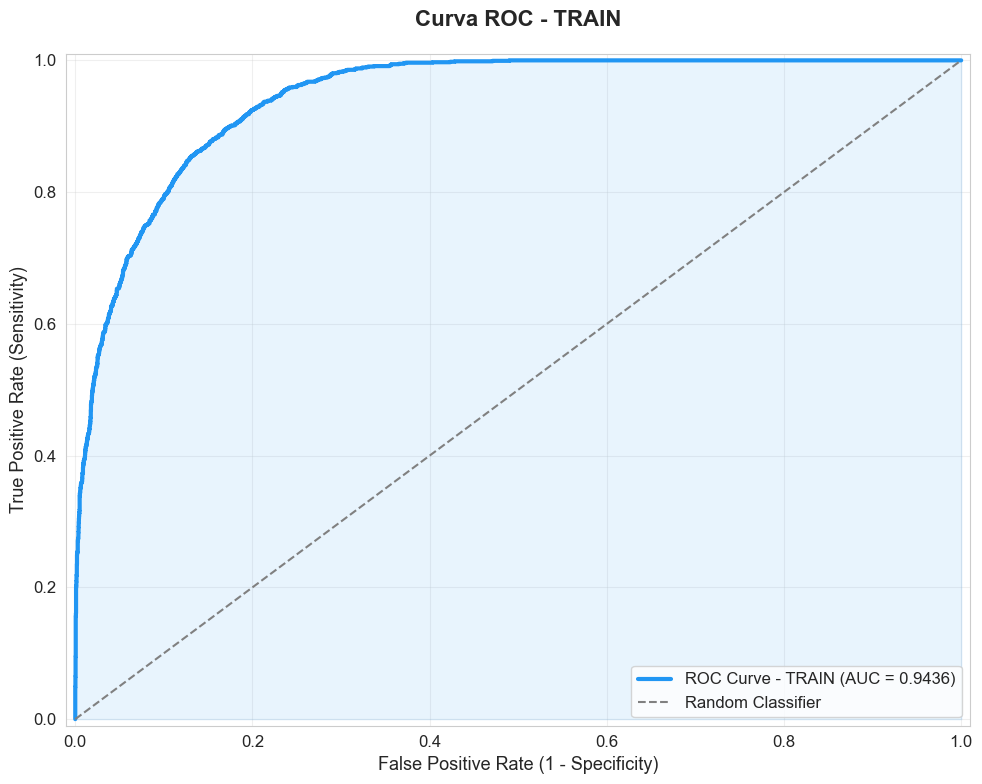

In [37]:
# ============================================
# CURVA ROC - TRAIN
# ============================================

plt.figure(figsize=(10, 8))
plt.plot(metrics_train['fpr'], metrics_train['tpr'], color='#2196F3', linewidth=3,
         label=f'ROC Curve - TRAIN (AUC = {metrics_train["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(metrics_train['fpr'], metrics_train['tpr'], alpha=0.1, color='#2196F3')
plt.title('Curva ROC - TRAIN', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves', 'roc_curve_train.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.2 Curva ROC - VALIDATION

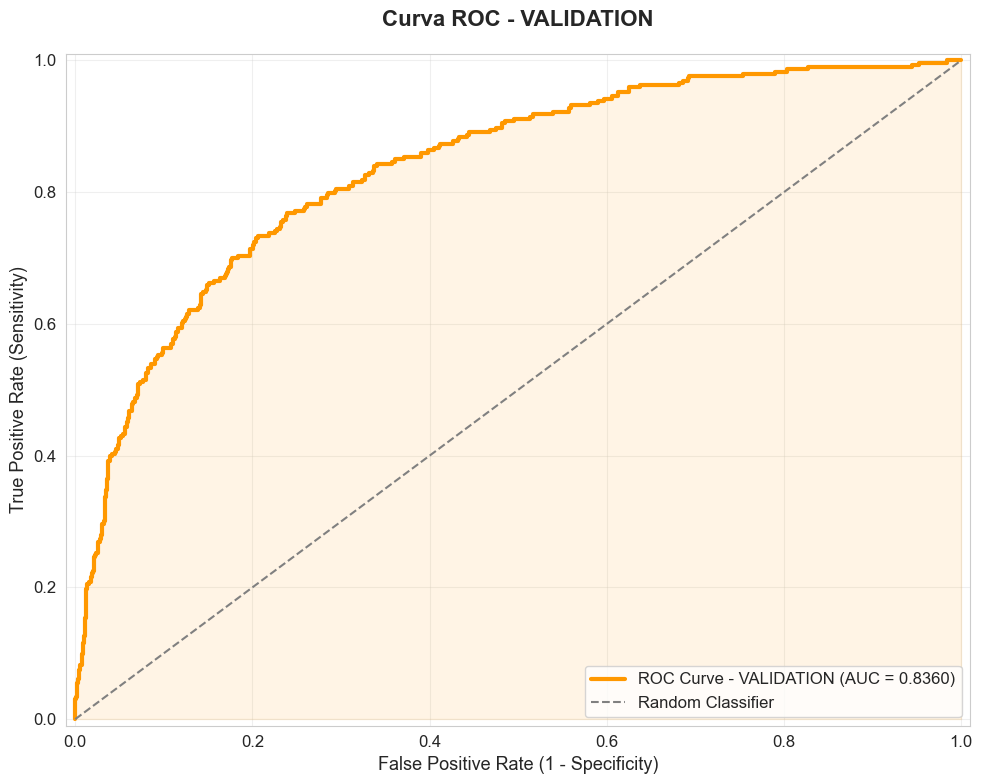

In [167]:
# ============================================
# CURVA ROC - VALIDATION
# ============================================

plt.figure(figsize=(10, 8))
plt.plot(metrics_val['fpr'], metrics_val['tpr'], color='#FF9800', linewidth=3,
         label=f'ROC Curve - VALIDATION (AUC = {metrics_val["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(metrics_val['fpr'], metrics_val['tpr'], alpha=0.1, color='#FF9800')
plt.title('Curva ROC - VALIDATION', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves', 'roc_curve_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Curva ROC - TEST

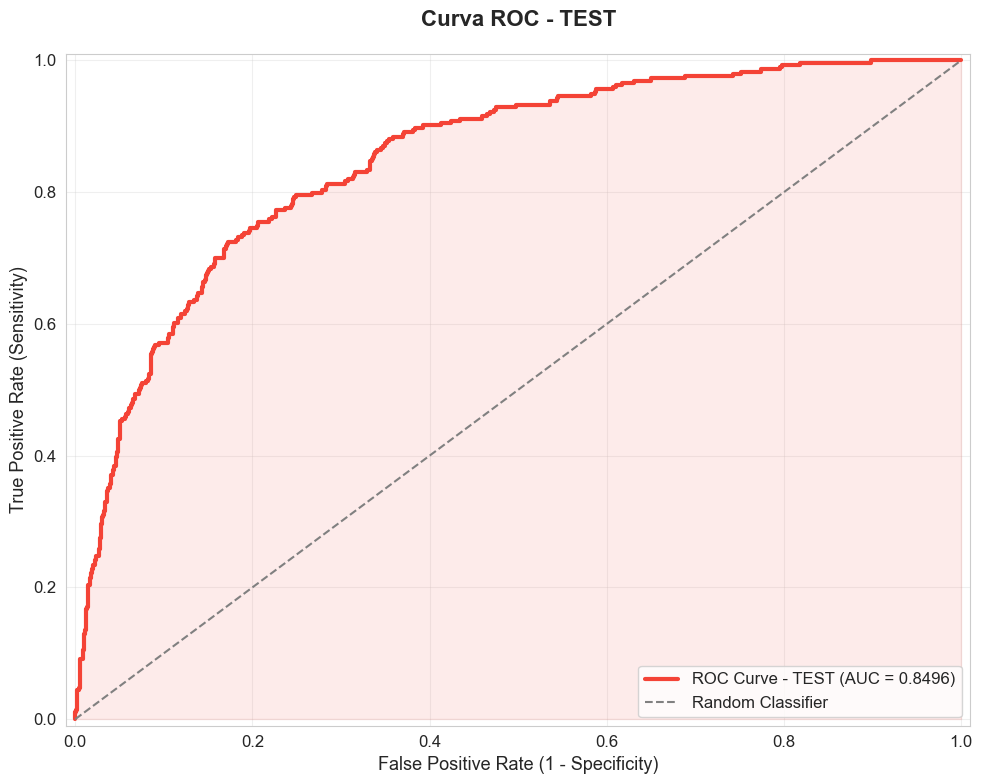

In [168]:
# ============================================
# CURVA ROC - TEST
# ============================================

plt.figure(figsize=(10, 8))
plt.plot(metrics_test['fpr'], metrics_test['tpr'], color='#F44336', linewidth=3,
         label=f'ROC Curve - TEST (AUC = {metrics_test["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(metrics_test['fpr'], metrics_test['tpr'], alpha=0.1, color='#F44336')
plt.title('Curva ROC - TEST', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves', 'roc_curve_test.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.4 Comparación de Curvas ROC (Train vs Validation vs Test)

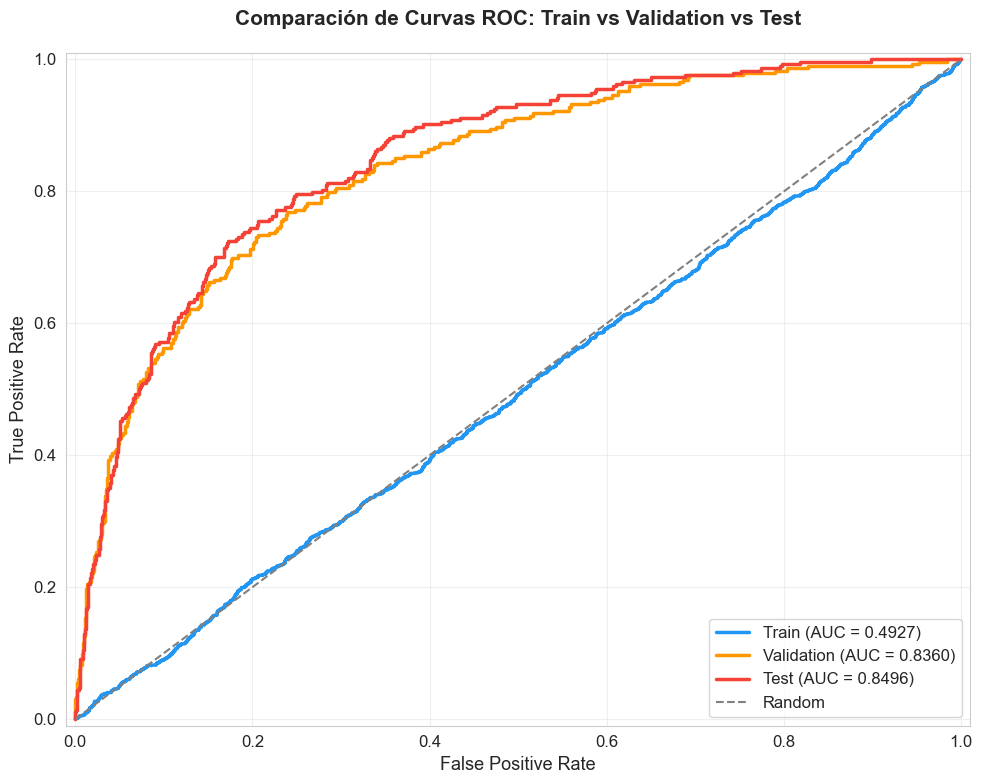

In [169]:
# ============================================
# COMPARACIÓN DE CURVAS ROC
# ============================================

plt.figure(figsize=(10, 8))

plt.plot(metrics_train['fpr'], metrics_train['tpr'], color='#2196F3', linewidth=2.5,
         label=f'Train (AUC = {metrics_train["roc_auc"]:.4f})')
plt.plot(metrics_val['fpr'], metrics_val['tpr'], color='#FF9800', linewidth=2.5,
         label=f'Validation (AUC = {metrics_val["roc_auc"]:.4f})')
plt.plot(metrics_test['fpr'], metrics_test['tpr'], color='#F44336', linewidth=2.5,
         label=f'Test (AUC = {metrics_test["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random')

plt.title('Comparación de Curvas ROC: Train vs Validation vs Test',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves', 'roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Comparación Final de Métricas

Tabla resumen con todas las métricas para los tres conjuntos de datos.

In [170]:
# ============================================
# TABLA COMPARATIVA DE MÉTRICAS
# ============================================

comparison_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Train': [
        metrics_train['accuracy'],
        metrics_train['precision'],
        metrics_train['recall'],
        metrics_train['f1_score'],
        metrics_train['roc_auc']
    ],
    'Validation': [
        metrics_val['accuracy'],
        metrics_val['precision'],
        metrics_val['recall'],
        metrics_val['f1_score'],
        metrics_val['roc_auc']
    ],
    'Test': [
        metrics_test['accuracy'],
        metrics_test['precision'],
        metrics_test['recall'],
        metrics_test['f1_score'],
        metrics_test['roc_auc']
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.round(4)

print('=' * 60)
print('  COMPARACIÓN FINAL DE MÉTRICAS')
print('=' * 60)
print()
print(df_comparison.to_string(index=False))

# Guardar en CSV
df_comparison.to_csv(os.path.join(RESULTS_DIR, 'metrics', 'comparison_all_splits.csv'), index=False)
print(f'\nTabla guardada en: {os.path.join(RESULTS_DIR, "metrics", "comparison_all_splits.csv")}')

df_comparison

  COMPARACIÓN FINAL DE MÉTRICAS

  Métrica  Train  Validation   Test
 Accuracy 0.7355      0.8475 0.8464
Precision 0.6821      0.8333 0.8316
   Recall 0.7355      0.8475 0.8464
 F1-Score 0.7048      0.8337 0.8312
  ROC-AUC 0.4927      0.8360 0.8496

Tabla guardada en: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\results\metrics\comparison_all_splits.csv


,Métrica,Train,Validation,Test
0,Accuracy,0.7355,0.8475,0.8464
1,Precision,0.6821,0.8333,0.8316
2,Recall,0.7355,0.8475,0.8464
3,F1-Score,0.7048,0.8337,0.8312
4,ROC-AUC,0.4927,0.8360,0.8496


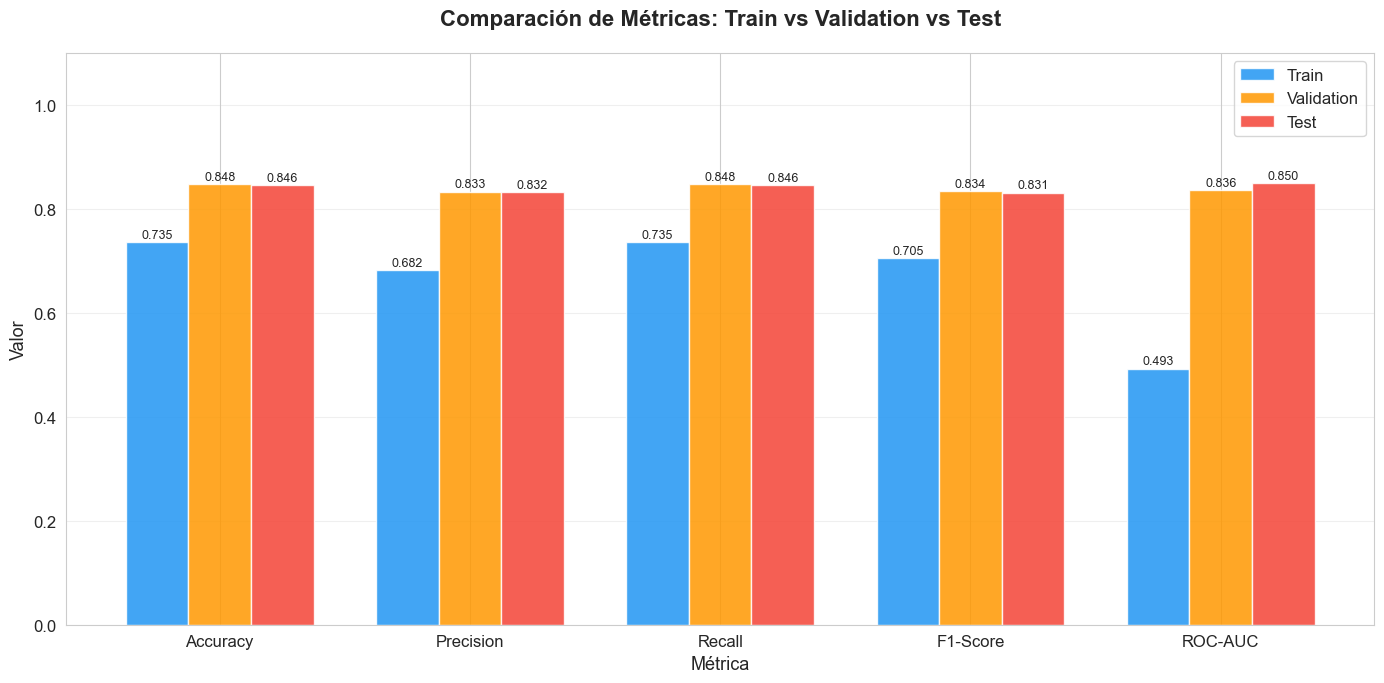

In [171]:
# ============================================
# GRÁFICA COMPARATIVA DE MÉTRICAS
# ============================================

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
train_vals = [metrics_train['accuracy'], metrics_train['precision'], metrics_train['recall'],
              metrics_train['f1_score'], metrics_train['roc_auc']]
val_vals = [metrics_val['accuracy'], metrics_val['precision'], metrics_val['recall'],
            metrics_val['f1_score'], metrics_val['roc_auc']]
test_vals = [metrics_test['accuracy'], metrics_test['precision'], metrics_test['recall'],
             metrics_test['f1_score'], metrics_test['roc_auc']]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width, train_vals, width, label='Train', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x, val_vals, width, label='Validation', color='#FF9800', alpha=0.85)
bars3 = ax.bar(x + width, test_vals, width, label='Test', color='#F44336', alpha=0.85)

ax.set_title('Comparación de Métricas: Train vs Validation vs Test',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Métrica', fontsize=13)
ax.set_ylabel('Valor', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Valores sobre barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics', 'metrics_comparison_barplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Interpretación de Resultados

### 12.1 Análisis de las Métricas

**Accuracy:** Proporción total de predicciones correctas. Útil cuando las clases están balanceadas.

**Precision:** De todas las predicciones positivas (maligno), ¿cuántas son realmente malignas? Alta precision = pocos falsos positivos.

**Recall (Sensitivity):** De todos los casos realmente malignos, ¿cuántos detectó el modelo? Alto recall = pocos falsos negativos. **Crítico en diagnóstico médico.**

**F1-Score:** Media armónica de Precision y Recall. Balance entre ambas métricas.

**ROC-AUC:** Capacidad del modelo para discriminar entre clases. AUC=1.0 es perfecto, AUC=0.5 es aleatorio.

### 12.2 Análisis de Overfitting

Comparando las métricas entre Train y Test:
- Si Train >> Test: **Overfitting** (el modelo memoriza datos de entrenamiento)
- Si Train ≈ Test: **Buena generalización**
- Si Train < Test: Posible **underfitting** o varianza en los datos

### 12.3 Importancia Clínica

En diagnóstico de cáncer, el **Recall** es especialmente importante:
- Un falso negativo (no detectar un cáncer) es más peligroso que un falso positivo
- Se prefiere alta sensibilidad aunque implique más falsos positivos
- Los falsos positivos se resuelven con exámenes adicionales

## 13. Predicción sobre Nuevas Imágenes

Predicción ejemplo (Benigno):


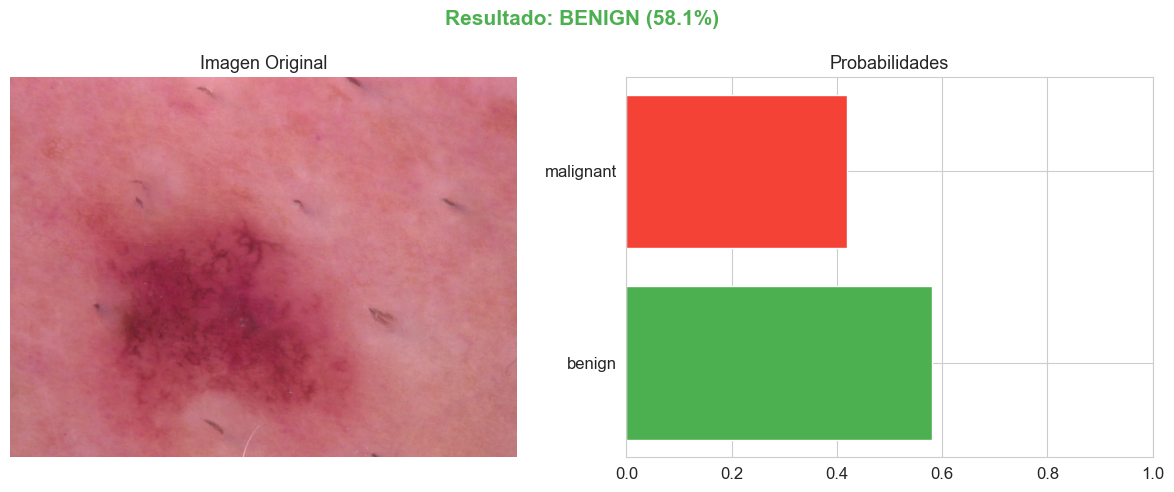


Predicción ejemplo (Maligno):


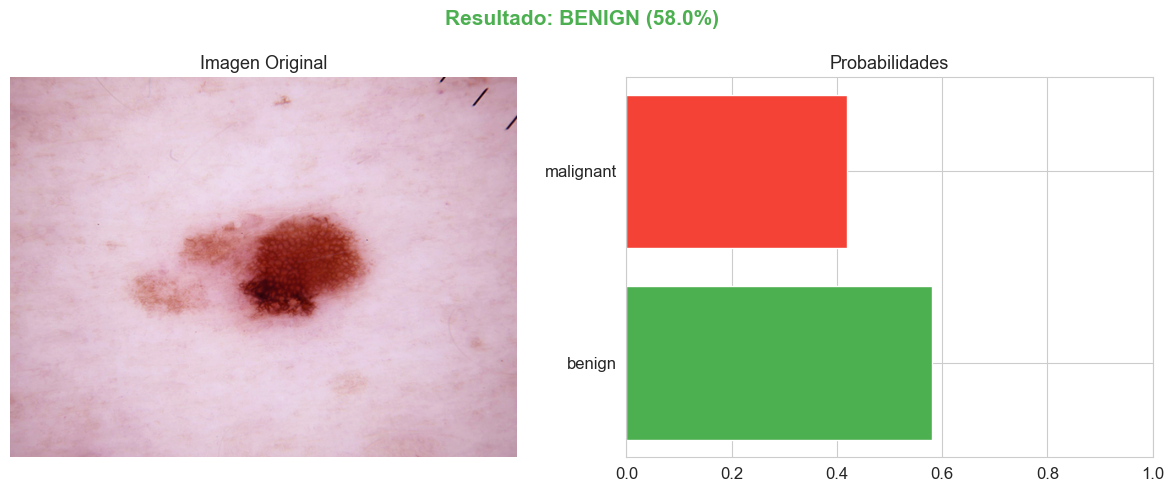

In [172]:
# ============================================
# EJEMPLO DE PREDICCIÓN
# ============================================

def predict_and_display(model, image_path, class_names):
    """Predice y muestra resultado para una imagen."""
    # Cargar y preprocesar
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(IMG_SIZE)
    img_array = np.array(img_resized).astype('float32') / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Predecir
    predictions = model.predict(img_batch, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx]
    predicted_class = class_names[predicted_idx]
    
    # Mostrar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title('Imagen Original', fontsize=13)
    axes[0].axis('off')
    
    colors = ['#4CAF50', '#F44336']
    axes[1].barh(class_names, predictions[0], color=colors)
    axes[1].set_title('Probabilidades', fontsize=13)
    axes[1].set_xlim([0, 1])
    
    result_text = f'Resultado: {predicted_class.upper()} ({confidence*100:.1f}%)'
    fig.suptitle(result_text, fontsize=15, fontweight='bold',
                 color='#F44336' if predicted_class == 'malignant' else '#4CAF50')
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

# Ejemplo con imágenes del test set
test_benign_dir = os.path.join(TEST_DIR, 'benign')
test_malignant_dir = os.path.join(TEST_DIR, 'malignant')

if os.path.exists(test_benign_dir) and os.listdir(test_benign_dir):
    sample_img = os.path.join(test_benign_dir, os.listdir(test_benign_dir)[0])
    print('Predicción ejemplo (Benigno):')
    predict_and_display(model, sample_img, CLASS_NAMES)

if os.path.exists(test_malignant_dir) and os.listdir(test_malignant_dir):
    sample_img = os.path.join(test_malignant_dir, os.listdir(test_malignant_dir)[0])
    print('\nPredicción ejemplo (Maligno):')
    predict_and_display(model, sample_img, CLASS_NAMES)

## 14. Conclusiones

### 14.1 Resumen del Proyecto

Se desarrolló exitosamente un sistema de clasificación de cáncer de piel basado en Deep Learning con las siguientes características:

1. **Dataset:** HAM10000 con 10,015 imágenes dermatoscópicas, clasificadas en benigno/maligno
2. **Modelo:** EfficientNetB0 con Transfer Learning desde ImageNet
3. **Preprocesamiento:** Resize 224x224, normalización, data augmentation
4. **Evaluación:** Métricas completas en Train, Validation y Test

- Despliegue containerizado con Docker


In [173]:
# ============================================
# RESUMEN FINAL
# ============================================

print('=' * 60)
print('  PROYECTO COMPLETADO EXITOSAMENTE')
print('=' * 60)
print()
print('Archivos generados:')
print(f'  Modelo: {MODEL_PATH}')
print(f'  Métricas: {os.path.join(RESULTS_DIR, "metrics")}')
print(f'  Matrices de confusión: {os.path.join(RESULTS_DIR, "confusion_matrix")}')
print(f'  Curvas ROC: {os.path.join(RESULTS_DIR, "roc_curves")}')
print(f'  Gráficas entrenamiento: {os.path.join(RESULTS_DIR, "training")}')
print()
print('Para ejecutar la aplicación web:')
print('  streamlit run src/app.py')
print()
print('Para ejecutar con Docker:')
print('  cd docker && docker-compose up --build')
print()
print('Skin Cancer Classification using Deep Learning')
print('EfficientNetB0 + Transfer Learning | HAM10000 Dataset')

  PROYECTO COMPLETADO EXITOSAMENTE

Archivos generados:
  Modelo: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\models\best_model.h5
  Métricas: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\results\metrics
  Matrices de confusión: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\results\confusion_matrix
  Curvas ROC: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\results\roc_curves
  Gráficas entrenamiento: c:\Users\Sebas\Desktop\ML-CANCERPIEL\SkinCancerClassifier\results\training

Para ejecutar la aplicación web:
  streamlit run src/app.py

Para ejecutar con Docker:
  cd docker && docker-compose up --build

Skin Cancer Classification using Deep Learning
EfficientNetB0 + Transfer Learning | HAM10000 Dataset
